In [28]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import numpy as np
import pandas as pd
import os
import glob
from PIL import Image

# ==========================================
# CẤU HÌNH THÔNG SỐ
# ==========================================
#! ĐỪNG ĐỤNG
IMG_HEIGHT = 32
IMG_WIDTH = 32
NUM_CLASSES = 10
# ĐỤNG ĐƯỢC
EPOCHS = 30
BATCH_SIZE = 32
DROPOUT_RATE = 0.2 # thừa khớp - overfitting
PATIENCE = 5 # Accuracy - Loss - Val_accuracy - Val_loss
VAL_SPLIT = 0.3 # Tỷ lệ validation (VAL_SPLIT để validation)

# ĐƯỜNG DẪN DATASET (Bạn sẽ cập nhật sau)
TRAIN_DIR = 'C:/DUT/Ki 2/Edge AI/dataset/train'
TEST_DIR = 'C:/DUT/Ki 2/Edge AI/dataset/test'

# ==========================================
# NẠP VÀ TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
# Chia tập train thành 80% train và 20% validation
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Chuẩn hóa giá trị pixel về [0, 1] (rất quan trọng cho việc huấn luyện)
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Tối ưu hóa pipeline nạp dữ liệu
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

def build_micro_model():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(16, (3, 3), padding='same', activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)), # output: 16x16x16
        
        # Block 2
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)), # output: 8x8x32
        
        # Block 3
        layers.Conv2D(80, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)), # output: 4x4x64
        
        # Classifier
        layers.Flatten(), # output: 1024
        layers.Dense(128, activation='relu'), # Param = 1024*128 + 128 = 131,200
        layers.Dropout(DROPOUT_RATE), # Chống overfitting
        layers.Dense(NUM_CLASSES, activation='softmax') # Param = 128*10 + 10 = 1,290
    ])
    return model

model = build_micro_model()

# --- Custom Callback để theo dõi kỷ lục Accuracy ---
class AccuracyTracker(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.best_val_acc = 0.0
        self.best_val_loss = 10.0

    def on_epoch_end(self, epoch, logs=None):
        current_val_acc = logs.get("val_accuracy")
        current_val_loss = logs.get("val_loss")
        if current_val_acc > self.best_val_acc:
            diff = current_val_acc - self.best_val_acc
            print(f"\n✅ Epoch {epoch+1}: Val-Accuracy tăng thêm {diff:.4f}! (Từ {self.best_val_acc:.4f} -> {current_val_acc:.4f})")
            self.best_val_acc = current_val_acc
        else:
            print(f"\n⚠️ Epoch {epoch+1}: Val-Accuracy không tăng (Hiện tại: {current_val_acc:.4f} - Kỷ lục: {self.best_val_acc:.4f})")
        if current_val_loss < self.best_val_loss:
            diff_loss = self.best_val_loss - current_val_loss
            print(f"✅ Epoch {epoch+1}: Val-Loss giảm thêm {diff_loss:.4f}! (Từ {self.best_val_loss:.4f} -> {current_val_loss:.4f})")
            self.best_val_loss = current_val_loss
        else:
            print(f"⚠️ Epoch {epoch+1}: Val-Loss không giảm (Hiện tại: {current_val_loss:.4f} - Kỷ lục: {self.best_val_loss:.4f})")

# Compile model
model.compile(optimizer='adam',
            loss=tf.keras.losses.SparseCategoricalCrossentropy(),
            metrics=['accuracy'])

# Kiểm tra tổng số parameters (Chắc chắn phải < 200.000)
model.summary()

# Tạo callback lưu model tốt nhất
checkpoint = callbacks.ModelCheckpoint(
    'traffic_sign_model.h5', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max',
    verbose=1
)

# Giảm LR khi loss đi ngang
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2,        # Giảm LR đi 5 lần (LR = LR * 0.2)
    patience=5,         # Đợi 5 epoch nếu loss không giảm thì mới giảm LR
    min_lr=1e-6,       # LR tối thiểu không được thấp hơn mức này
    verbose=1
)

# Callback dừng sớm nếu không cải thiện
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=PATIENCE, 
    restore_best_weights=True
)

# Tiến hành huấn luyện
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[AccuracyTracker(), reduce_lr, checkpoint, early_stopping]
)

print("Đã lưu model gốc: traffic_sign_model.h5")


# Tải lại model tốt nhất vừa lưu
best_model = tf.keras.models.load_model('traffic_sign_model.h5')

# Khởi tạo TFLite Converter
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Tạo generator cho Representative Dataset (Dùng tập train để TFLite biết dải phân bố dữ liệu)
def representative_dataset():
    for images, _ in train_ds.take(100):
        yield [images]

converter.representative_dataset = representative_dataset

# Ép chặt I/O và các phép toán về INT8
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8  # Input là int8
converter.inference_output_type = tf.int8 # Output là int8

# Chuyển đổi và lưu file .tflite
tflite_quant_model = converter.convert()

with open('traffic_sign_model_quantized.tflite', 'wb') as f:
    f.write(tflite_quant_model)




# Load TFLite Model
interpreter = tf.lite.Interpreter(model_path="traffic_sign_model_quantized.tflite")
interpreter.allocate_tensors()

# Lấy thông tin Input/Output
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_scale, input_zero_point = input_details[0]['quantization']
output_scale, output_zero_point = output_details[0]['quantization']

# Lấy danh sách ảnh test
test_images_paths = glob.glob(os.path.join(TEST_DIR, '*.png')) # Hoặc .jpg tùy format của bạn
test_images_paths.sort() # Sắp xếp để đảm bảo đúng thứ tự

results = []

for img_path in test_images_paths:
    # Trích xuất Id (tên file không có đuôi) - vd: '00000.png' -> '00000'
    img_id = os.path.basename(img_path).split('.')[0]
    
    # Tiền xử lý ảnh (giống hệt lúc train)
    img = Image.open(img_path).convert('RGB').resize((IMG_WIDTH, IMG_HEIGHT))
    img_array = np.array(img, dtype=np.float32) / 255.0 # Chuẩn hóa
    
    # Chuyển đổi Input về INT8 dựa trên scale và zero_point của TFLite
    if input_scale != 0:
        img_array = img_array / input_scale + input_zero_point
    img_array = np.expand_dims(img_array.astype(np.int8), axis=0)
    
    # Dự đoán
    interpreter.set_tensor(input_details[0]['index'], img_array)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])[0]
    
    # Decode Output từ INT8 về giá trị thật (nếu cần thiết, hoặc lấy luôn argmax)
    # Vì argmax của int8 cũng chính là argmax của probability
    predicted_class = np.argmax(output_data)
    
    results.append({'Id': img_id, 'Label': predicted_class})

# Tạo DataFrame và xuất file CSV
submission_df = pd.DataFrame(results)
submission_df.to_csv('submission.csv', index=False)

print("Đã xuất file: submission.csv")
print(submission_df.head())
print(f"Kích thước model TFLite (Int8): {len(tflite_quant_model) / 1024:.2f} KB")
final_loss = history.history['loss'][-1] * 100
final_acc = history.history['accuracy'][-1] * 100
final_val_loss = history.history['val_loss'][-1] * 100
final_val_acc = history.history['val_accuracy'][-1] * 100

print(f"Kết quả cuối cùng: Acc: {final_acc:.2f}%, Loss: {final_loss:.2f}%")
print(f"Kiểm chứng cuối cùng: Val_Acc: {final_val_acc:.2f}%, Val_Loss: {final_val_loss:.2f}%")

Found 2000 files belonging to 10 classes.
Using 1400 files for training.
Found 2000 files belonging to 10 classes.
Using 600 files for validation.


c:\Users\ngong\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_54 (Conv2D)              │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 8, 8, 80)       │        23,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 8, 8, 80)       │           320 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_56 (MaxPooling2D) │ (None, 4, 4, 80)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,978 (757.73 KB)

...

INFO:tensorflow:Assets written to: C:\Users\ngong\AppData\Local\Temp\tmp9n4qnf_7\assets


INFO:tensorflow:Assets written to: C:\Users\ngong\AppData\Local\Temp\tmp9n4qnf_7\assets


Saved artifact at 'C:\Users\ngong\AppData\Local\Temp\tmp9n4qnf_7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='input_layer_18')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2857458076368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2857458075216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2857458075408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2857458074256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2857458075024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2857458075600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2857458075984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2857458078672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2857458078096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2857458079056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2857

c:\Users\ngong\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
c:\Users\ngong\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Đã xuất file: submission.csv
      Id  Label
0  00000      4
1  00007      2
2  00012      2
3  00014      5
4  00022      1
Kích thước model TFLite (Int8): 202.87 KB
Kết quả cuối cùng: Acc: 100.00%, Loss: 0.02%
Kiểm chứng cuối cùng: Val_Acc: 99.50%, Val_Loss: 1.63%


# After

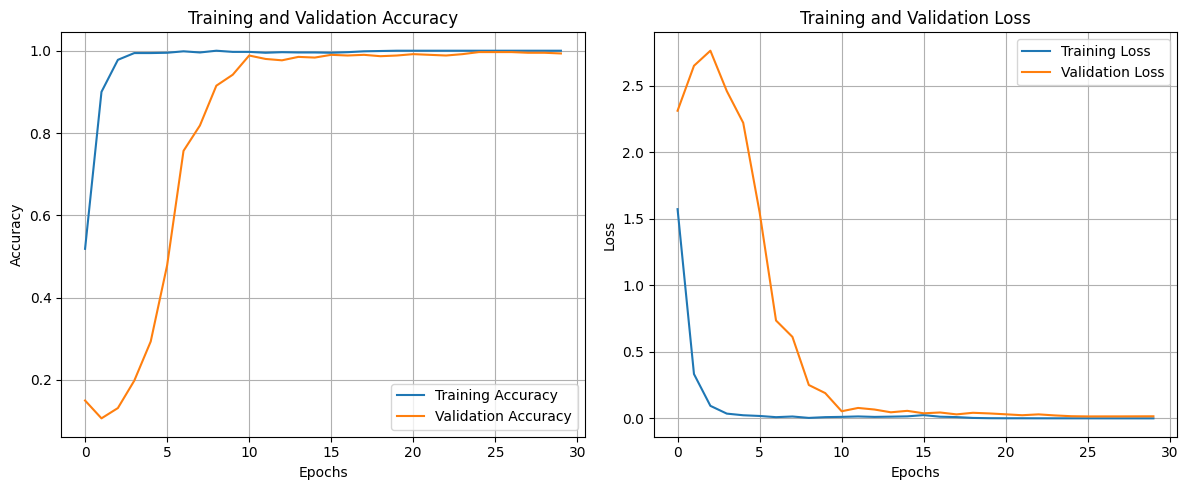

In [27]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Biểu đồ Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Biểu đồ Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Gọi hàm sau khi train xong
plot_history(history)

# Before

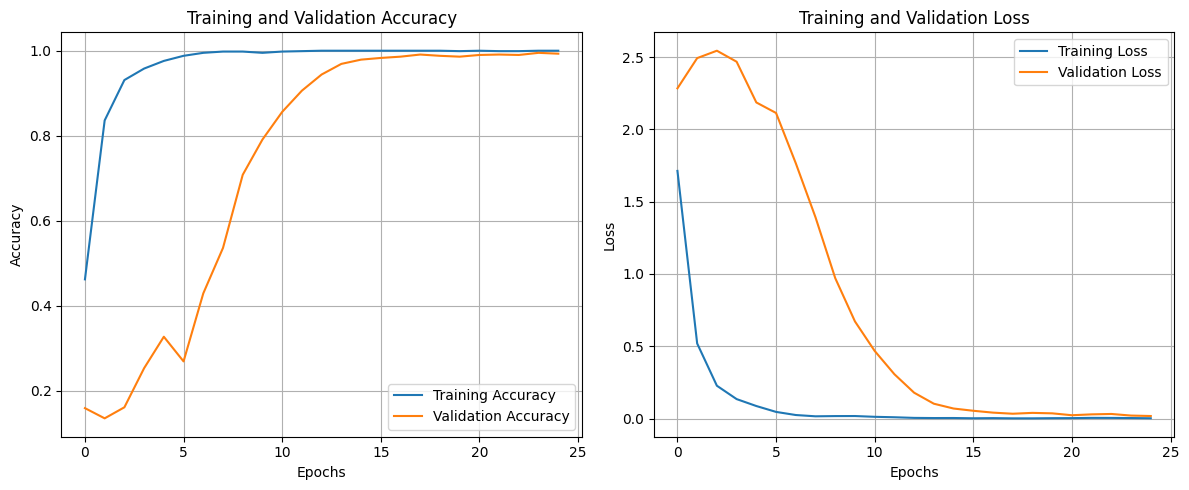

In [20]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Biểu đồ Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Biểu đồ Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Gọi hàm sau khi train xong
plot_history(history)